In [1]:
# Cell 1 — Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [2]:
# Cell 2 — Create the dataset
df = pd.DataFrame(
    [
        [8, 8, 1],
        [7, 9, 1],
        [6, 10, 0],
        [5, 5, 0],
    ],
    columns=['cgpa', 'profile_score', 'placed']
)

df

,cgpa,profile_score,placed
0,8,8,1
1,7,9,1
2,6,10,0
3,5,5,0


In [3]:
# Cell 3 — Prepare X and y
X = df[['cgpa', 'profile_score']].values.astype(float)
y = df[['placed']].values.astype(float)

# For matrix-based neural-network calculations, use:
# X.shape = (number_of_features, number_of_examples)
# y.shape = (1, number_of_examples)
X = X.T
y = y.T

print('X shape:', X.shape)
print('y shape:', y.shape)
print('\nX =')
print(X)
print('\ny =')
print(y)

X shape: (2, 4)
y shape: (1, 4)

X =
[[ 8.  7.  6.  5.]
 [ 8.  9. 10.  5.]]

y =
[[1. 1. 0. 0.]]


In [4]:
# Cell 4 — Optional feature scaling
# Scaling makes gradient-based learning more stable.
# The minimum/maximum values are learned from the current dataset only.
X_min = X.min(axis=1, keepdims=True)
X_max = X.max(axis=1, keepdims=True)
X_scaled = (X - X_min) / (X_max - X_min + 1e-8)

print('Scaled X =')
print(X_scaled)

Scaled X =
[[1.       0.666667 0.333333 0.      ]
 [0.6      0.8      1.       0.      ]]


In [5]:
# Cell 5 — Sigmoid activation and derivative
def sigmoid(z):
    """Convert any real number into a probability between 0 and 1."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def sigmoid_derivative(a):
    """Derivative of sigmoid when 'a' is already sigmoid(z)."""
    return a * (1.0 - a)

In [6]:
# Cell 6 — Initialize weights and biases
def initialize_parameters(n_x, n_h, n_y, seed=42):
    """Initialize parameters for a 2 -> 2 -> 1 network."""
    rng = np.random.default_rng(seed)

    W1 = rng.normal(0, 0.5, size=(n_h, n_x))
    b1 = np.zeros((n_h, 1))
    W2 = rng.normal(0, 0.5, size=(n_y, n_h))
    b2 = np.zeros((n_y, 1))

    return {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}


parameters = initialize_parameters(
    n_x=X_scaled.shape[0],
    n_h=2,
    n_y=1,
    seed=42
)

parameters

{'W1': array([[ 0.152359, -0.519992],
        [ 0.375226,  0.470282]]),
 'b1': array([[0.],
        [0.]]),
 'W2': array([[-0.975518, -0.65109 ]]),
 'b2': array([[0.]])}

In [7]:
# Cell 7 — Check parameter shapes
for name, value in parameters.items():
    print(f'{name}: shape={value.shape}\n{value}\n')

W1: shape=(2, 2)
[[ 0.152359 -0.519992]
 [ 0.375226  0.470282]]

b1: shape=(2, 1)
[[0.]
 [0.]]

W2: shape=(1, 2)
[[-0.975518 -0.65109 ]]

b2: shape=(1, 1)
[[0.]]



In [8]:
# Cell 8 — Forward propagation
def forward_propagation(X, parameters):
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']

    Z1 = W1 @ X + b1
    A1 = sigmoid(Z1)

    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)

    cache = {
        'X': X,
        'Z1': Z1,
        'A1': A1,
        'Z2': Z2,
        'A2': A2,
    }

    return A2, cache

In [9]:
# Cell 9 — Test forward propagation before training
y_hat, cache = forward_propagation(X_scaled, parameters)

print('A1 (hidden layer activation):')
print(cache['A1'])

print('\nA2 / y_hat (output probabilities):')
print(y_hat)

A1 (hidden layer activation):
[[0.460175 0.422036 0.384804 0.5     ]
 [0.658675 0.651667 0.644593 0.5     ]]

A2 / y_hat (output probabilities):
[[0.293641 0.302378 0.311081 0.307187]]


In [10]:
# Cell 10 — Binary cross-entropy loss
def compute_loss(y, y_hat):
    """Average binary cross-entropy loss."""
    m = y.shape[1]
    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1 - eps)

    loss = -(1 / m) * np.sum(
        y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)
    )
    return float(loss)


loss = compute_loss(y, y_hat)
print('Initial loss:', loss)

Initial loss: 0.7902748950091165


In [11]:
# Cell 11 — Backward propagation
def backward_propagation(y, parameters, cache):
    X = cache['X']
    A1 = cache['A1']
    A2 = cache['A2']

    W2 = parameters['W2']
    m = X.shape[1]

    # Output layer gradient
    dZ2 = A2 - y
    dW2 = (dZ2 @ A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    # Hidden layer gradient
    dA1 = W2.T @ dZ2
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = (dZ1 @ X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    grads = {
        'dW1': dW1,
        'db1': db1,
        'dW2': dW2,
        'db2': db2,
    }

    return grads


In [12]:
# Cell 12 — Calculate gradients once and inspect them
grads = backward_propagation(y, parameters, cache)

for name, value in grads.items():
    print(f'{name}: shape={value.shape}\n{value}\n')

dW1: shape=(2, 2)
[[0.064473 0.040916]
 [0.039167 0.02453 ]]

db1: shape=(2, 1)
[[0.047604]
 [0.027525]]

dW2: shape=(1, 2)
[[-0.086543 -0.141441]]

db2: shape=(1, 1)
[[-0.196428]]



In [13]:
# Cell 13 — Gradient descent parameter update
def update_parameters(parameters, grads, learning_rate=0.5):
    parameters['W1'] -= learning_rate * grads['dW1']
    parameters['b1'] -= learning_rate * grads['db1']
    parameters['W2'] -= learning_rate * grads['dW2']
    parameters['b2'] -= learning_rate * grads['db2']

    return parameters

In [14]:
# Cell 14 — Complete training loop
def train(X, y, hidden_units=2, learning_rate=0.5, epochs=5000, seed=42, print_every=500):
    parameters = initialize_parameters(
        n_x=X.shape[0],
        n_h=hidden_units,
        n_y=1,
        seed=seed
    )

    loss_history = []

    for epoch in range(1, epochs + 1):
        # 1. Forward propagation
        y_hat, cache = forward_propagation(X, parameters)

        # 2. Loss
        loss = compute_loss(y, y_hat)
        loss_history.append(loss)

        # 3. Backpropagation
        grads = backward_propagation(y, parameters, cache)

        # 4. Gradient descent update
        parameters = update_parameters(parameters, grads, learning_rate)

        if epoch == 1 or epoch % print_every == 0:
            print(f'Epoch {epoch:5d} | Loss = {loss:.6f}')

    return parameters, loss_history

In [15]:
# Cell 15 — Train the model
parameters, loss_history = train(
    X_scaled,
    y,
    hidden_units=2,
    learning_rate=1.0,
    epochs=5000,
    seed=42,
    print_every=500
)

Epoch     1 | Loss = 0.790275
Epoch   500 | Loss = 0.014510
Epoch  1000 | Loss = 0.005384
Epoch  1500 | Loss = 0.003173
Epoch  2000 | Loss = 0.002214
Epoch  2500 | Loss = 0.001686
Epoch  3000 | Loss = 0.001355
Epoch  3500 | Loss = 0.001128
Epoch  4000 | Loss = 0.000964
Epoch  4500 | Loss = 0.000841
Epoch  5000 | Loss = 0.000744


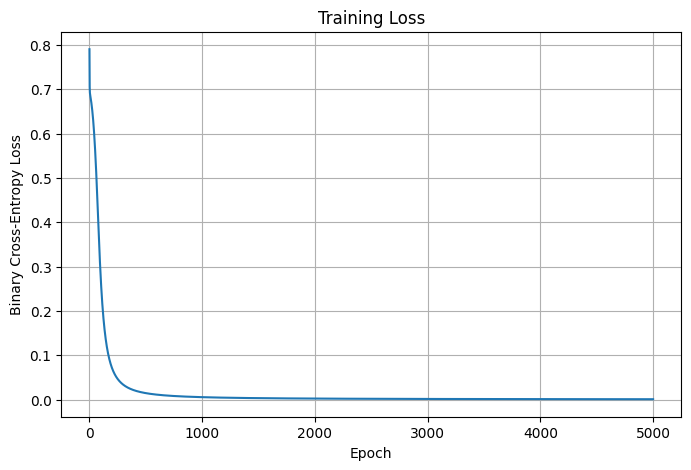

In [16]:
# Cell 16 — Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

In [17]:
# Cell 17 — Prediction function
def predict(X, parameters, threshold=0.5):
    """Return probabilities and binary predictions."""
    probabilities, _ = forward_propagation(X, parameters)
    predictions = (probabilities >= threshold).astype(int)
    return probabilities, predictions

In [18]:
# Cell 18 — Evaluate training data
probabilities, predictions = predict(X_scaled, parameters)
accuracy = np.mean(predictions == y) * 100

results = pd.DataFrame({
    'CGPA': df['cgpa'],
    'Profile Score': df['profile_score'],
    'Actual': df['placed'].astype(int),
    'Predicted Probability': probabilities.ravel(),
    'Predicted Class': predictions.ravel(),
})

print(f'Training accuracy: {accuracy:.2f}%')
results

Training accuracy: 100.00%


,CGPA,Profile Score,Actual,Predicted Probability,Predicted Class
0,8,8,1,0.9999,1
1,7,9,1,0.9985,1
2,6,10,0,0.0011,0
3,5,5,0,0.0003,0


In [19]:
# Cell 19 — Predict a new student
new_student = np.array([[7.5], [8.5]], dtype=float)

# Apply the training min/max scaling
new_student_scaled = (new_student - X_min) / (X_max - X_min + 1e-8)

new_probability, new_prediction = predict(new_student_scaled, parameters)

print('New student probability of placement:', float(new_probability[0, 0]))
print('Predicted class:', int(new_prediction[0, 0]))
print('Placed' if new_prediction[0, 0] == 1 else 'Not placed')

New student probability of placement: 0.9997938349002937
Predicted class: 1
Placed


In [20]:
# Cell 20 — Display learned parameters
for name, value in parameters.items():
    print(f'{name}:')
    print(value)
    print('-' * 50)

W1:
[[-10.788598   2.867168]
 [  4.670939  -1.009494]]
--------------------------------------------------
b1:
[[ 2.691324]
 [-1.188299]]
--------------------------------------------------
W2:
[[-13.903298   6.088992]]
--------------------------------------------------
b2:
[[3.312626]]
--------------------------------------------------
